Loading resource data...
  364 cities with resource data
Computing API (2020-2060 average)...
  332 cities matched

Top 10 cities by API_before:
    city  API_before  API_after  delta_API
  Yuulin    1.000000   0.577694  -0.422306
 Xiuqian    0.861207   0.230890  -0.630316
 Suuzhou    0.749784   0.684028  -0.065757
Taiizhou    0.521833   0.382571  -0.139262
 Yiichun    0.430050   0.180575  -0.249475
Binnzhou    0.405692   0.347841  -0.057852
Shaoyang    0.349201   0.216190  -0.133011
   Liuan    0.346283   0.172332  -0.173951
 Bazhong    0.343832   0.164778  -0.179054
Shaotong    0.334613   0.119825  -0.214788
  CSV saved -> /Users/shirley/Desktop/plots_V2/api_city.csv

Merging with shapefile...
Plotting Fig4...
Saved -> /Users/shirley/Desktop/plots_V2/Fig4_API_maps.png


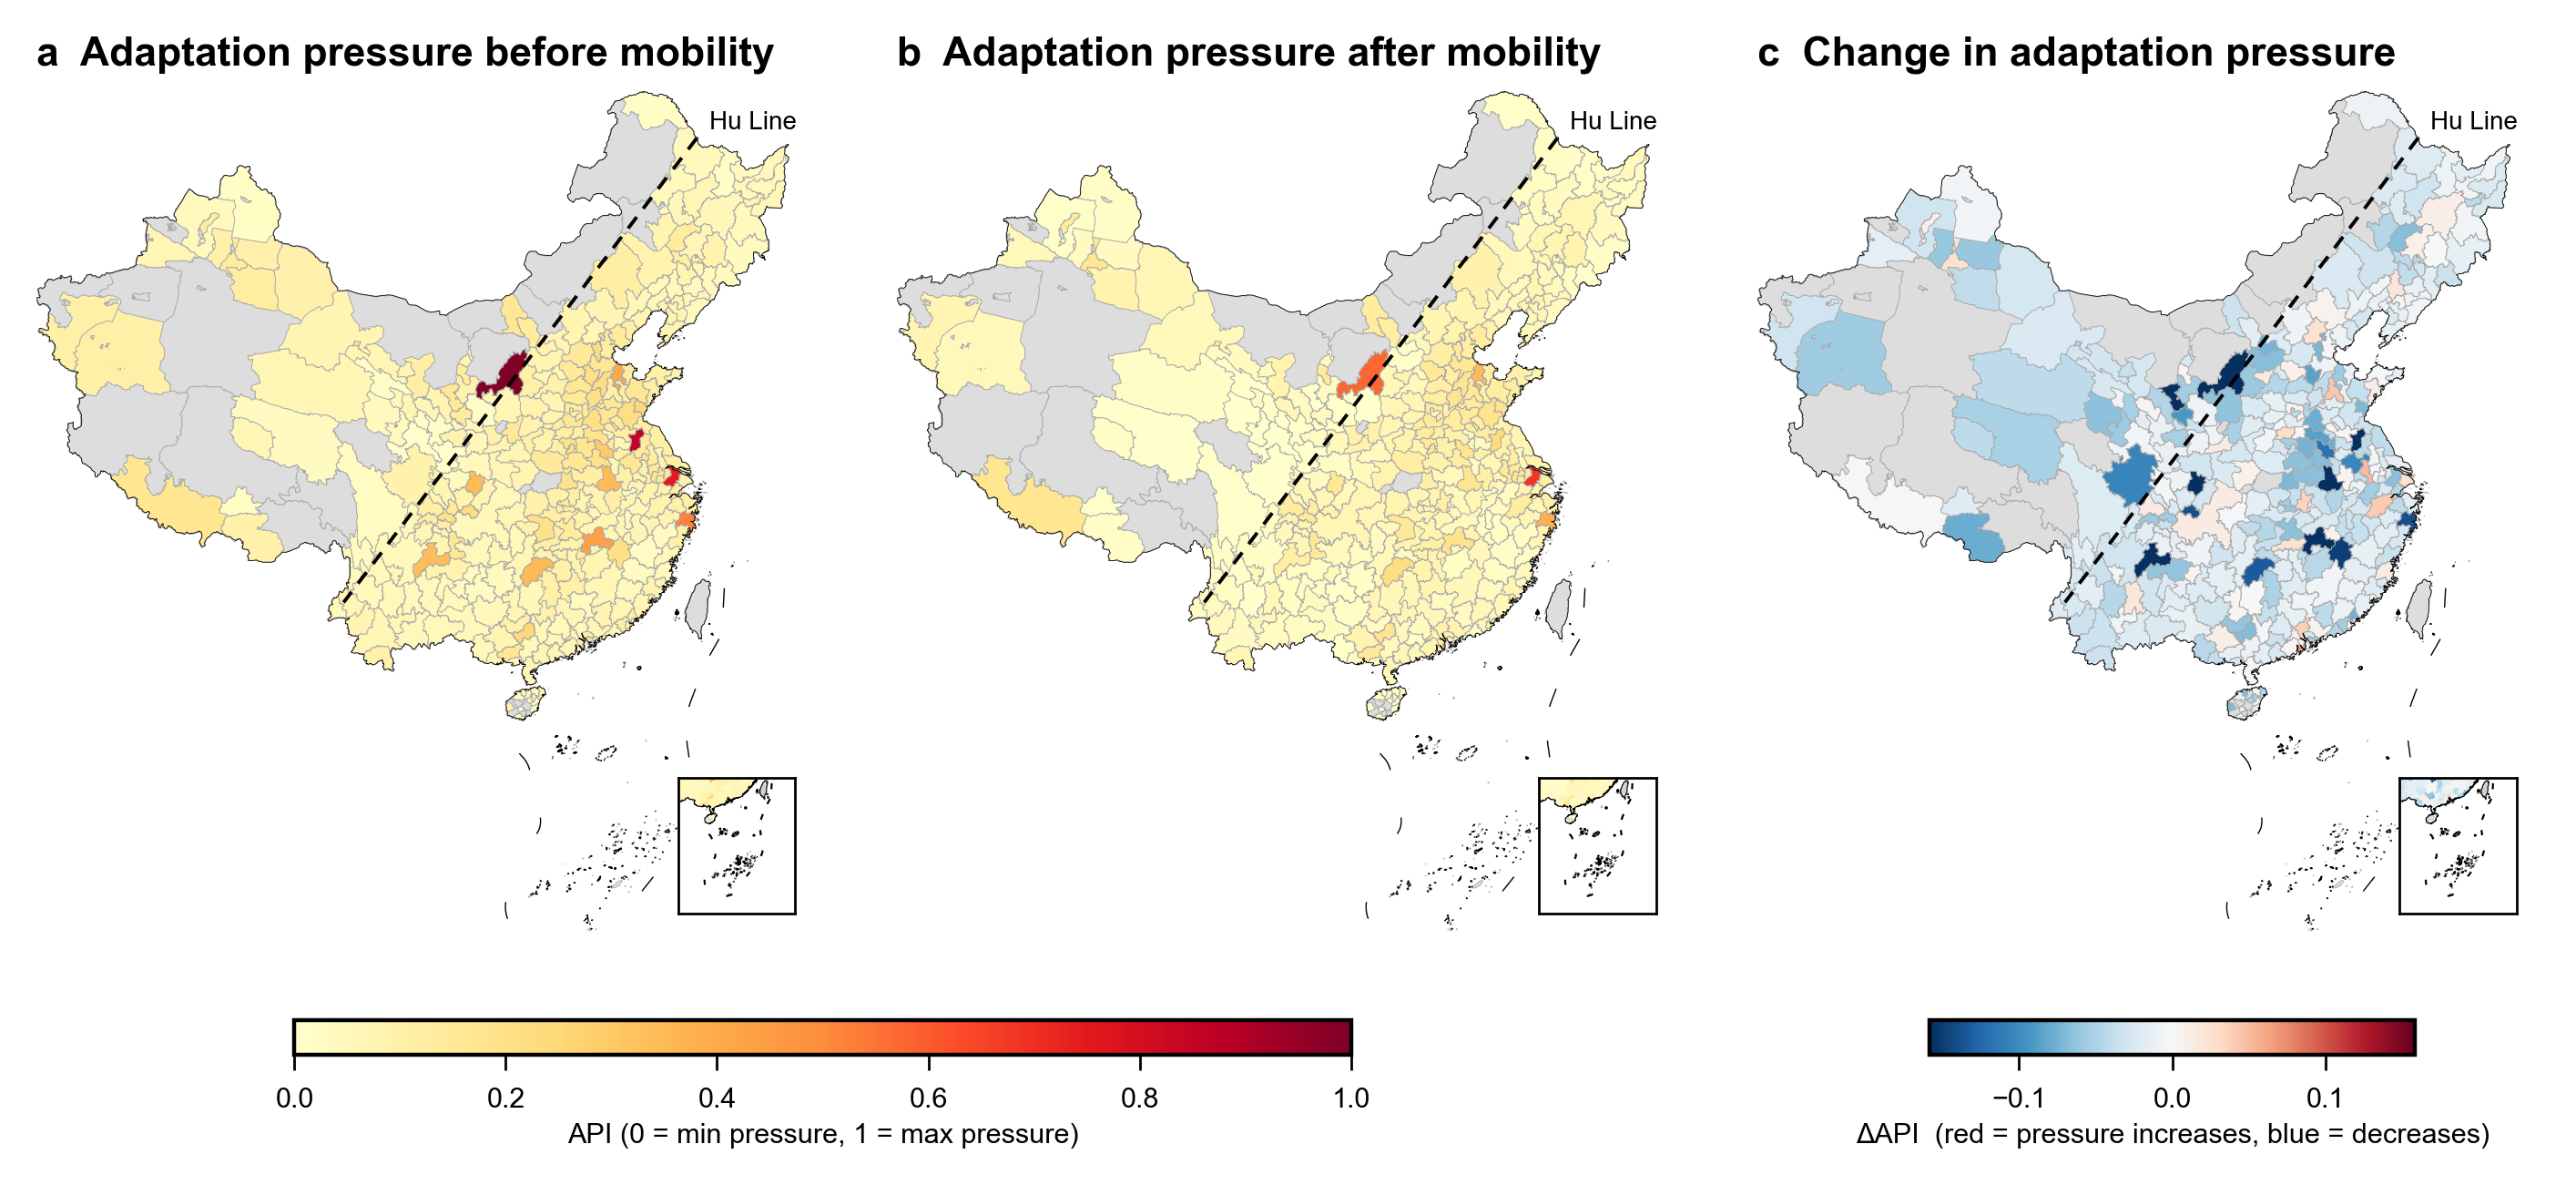

In [122]:
# =============================================================================
# Fig4: Adaptation Pressure Index (API) — 3 choropleth maps
# Maps: API before / API after / ΔAPI
# Format aligned with Fig3
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from shapely.geometry import box as shapely_box
from pyproj import Transformer
from adjustText import adjust_text

# ── 0. Paths & settings ───────────────────────────────────────────────────────
FLOW_DIR   = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
LOCAL_DIR  = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5/city_patient_sum")
INPUT_FILE = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/air_pollution/data source/hospital/13-National hospital directory.xlsx")
SHP_PATH   = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2 = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
OUTFILE    = Path("/Users/shirley/Desktop/plots_V2/Fig4_API_maps.png")
OUTFILE.parent.mkdir(parents=True, exist_ok=True)

SCENARIO = "earlypeak_NZ_CL"
YEARS    = [2020, 2030, 2040, 2050, 2060]
PROJ_STR = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

CITY_NAME_MAP = {
    "Wulumuqi":  "Urumqi",
    "Xian":      "Xi'an",
    "Qiqihaer":  "Qiqihar",
    "Huhehaote": "Hohhot",
    "Haerbin":   "Harbin",
}

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})

# ── 2. Spatial data ───────────────────────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)

city_shp_raw = gpd.read_file(SHP_PATH)
city_shp_raw["English"] = city_shp_raw["English"].str.strip().map(
    lambda x: CITY_NAME_MAP.get(x, x))
city_shp = city_shp_raw.to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y  = _hhy_transformer.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = city_shp.geometry.centroid.x
_cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")
region_map = (
    city_shp[["English", "region"]]
    .drop_duplicates(subset="English")
    .set_index("English")["region"]
    .to_dict()
)

# ── 3. Data loaders ───────────────────────────────────────────────────────────
def rename_idx(idx):
    return idx.str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))

def load_flow_matrix(year):
    path = FLOW_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = rename_idx(df.index)
    df.columns = rename_idx(df.columns)
    df = df.loc[~df.index.isin(["total"]), ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    return df

def load_citysum(year):
    path = LOCAL_DIR / f"citysum_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path)
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["local_patient", "mo_total"]].sum()

def compute_year(year):
    df_flow  = load_flow_matrix(year)
    df_local = load_citysum(year)
    inflow   = df_flow.sum(axis=0).groupby(level=0).sum()
    outflow  = df_flow.sum(axis=1).groupby(level=0).sum()
    all_cities = inflow.index.union(outflow.index)
    inflow   = inflow.reindex(all_cities, fill_value=0)
    outflow  = outflow.reindex(all_cities, fill_value=0)
    net      = (inflow - outflow).rename("net")
    df_local = df_local.groupby(level=0).sum()
    common   = net.index.intersection(df_local.index)
    out      = df_local.loc[common].copy()
    out["net"]    = net.loc[common].values
    out["demand"] = out["net"] + out["local_patient"]
    return out

# ── 4. Resource (static) ─────────────────────────────────────────────────────
def load_resource():
    df = pd.read_excel(INPUT_FILE, sheet_name="fig4")
    df = df[["city", "beds", "clinics"]].copy()
    df["beds"]    = pd.to_numeric(df["beds"],    errors="coerce")
    df["clinics"] = pd.to_numeric(df["clinics"], errors="coerce")
    df = df.dropna(subset=["city", "beds", "clinics"])
    df = df[(df["beds"] > 0) & (df["clinics"] > 0)]
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    df["resource"] = np.log(df["beds"] * df["clinics"])
    return df.groupby("city")["resource"].sum()

# ── 5. Compute API ────────────────────────────────────────────────────────────
def compute_api(resource):
    frames = [compute_year(y) for y in YEARS]
    avg    = pd.concat(frames).groupby(level=0).mean()
    common = avg.index.intersection(resource.index)
    avg    = avg.loc[common]
    res    = resource.loc[common]

    raw_before = avg["mo_total"] / res
    raw_after  = avg["demand"]   / res
    global_max = max(raw_before.max(), raw_after.max())

    api_before = raw_before / global_max
    api_after  = raw_after  / global_max
    delta_api  = api_after - api_before

    return pd.DataFrame({
        "city":       common,
        "API_before": api_before.values,
        "API_after":  api_after.values,
        "delta_API":  delta_api.values,
    })

# ── 6. Merge with shapefile ───────────────────────────────────────────────────
def build_shp(api_df):
    return city_shp.merge(api_df, left_on="English", right_on="city", how="left")

# ── 7. Nanhai inset helper ────────────────────────────────────────────────────
def _add_nanhai_inset(parent_ax, shp, col, norm, cmap):
    x1, y1, x2, y2 = _NANHAI_BOUNDS
    # 稍微向上或向左移动一点点 [left, bottom, width, height]，确保不贴着最边缘
    axins = parent_ax.inset_axes([0.82, 0.02, 0.15, 0.18])
    axins.set_facecolor("white")
    
    shp.plot(column=col, ax=axins, cmap=cmap, norm=norm,
             linewidth=0, missing_kwds={"color": "lightgrey"})
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)
    
    # 适当加大 Padding，给外框线留出足够的空间
    pad_x = (x2 - x1) * 0.08
    pad_y = (y2 - y1) * 0.08
    axins.set_xlim(x1 - pad_x, x2 + pad_x)
    axins.set_ylim(y1 - pad_y, y2 + pad_y)
    
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    
    # 显式设置外框
    for spine in axins.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")
        spine.set_clip_on(False)  # 关键：防止外框边线因裁剪变细或消失

# ── 8. Map base ───────────────────────────────────────────────────────────────
def _map_base(ax, shp, col, norm, cmap, title, panel):
    shp.plot(column=col, ax=ax, cmap=cmap, norm=norm,
             linewidth=0.15, edgecolor="#AAAAAA",
             missing_kwds={"color": "#DDDDDD"})
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.25)
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.7,
            linestyle="--", dashes=(4, 3), zorder=5)
    ax.text(_HHY_X[0] + 80000, _HHY_Y[0] + 60000,
            "Hu Line", fontsize=5, color="black", zorder=5)
    xmin, ymin, xmax, ymax = china_border.total_bounds
    height = ymax - ymin
    width  = xmax - xmin
    ax.set_xlim(xmin, xmax + width * 0.04)
    ax.set_ylim(ymin + height * 0.01, ymax + height * 0.01)
    ax.set_axis_off()
    ax.text(0, 1.01, f"{panel}  {title}",
            transform=ax.transAxes,
            fontsize=8, fontweight="bold",
            va="bottom", ha="left")
    _add_nanhai_inset(ax, shp, col, norm, cmap)

# ── 9. Map drawing functions ──────────────────────────────────────────────────
def draw_api_map(ax, shp, col, title, panel, norm, cmap, label_thresh=0.6):
    """API before/after map — labels cities above threshold."""
    _map_base(ax, shp, col, norm, cmap, title, panel)
    labeled = shp[shp[col] > label_thresh].dropna(subset=[col])
    texts = []
    for _, row in labeled.iterrows():
        if pd.isna(row.geometry):
            continue
        cx_r = row.geometry.centroid.x
        cy_r = row.geometry.centroid.y
        val  = row[col]
        name = row["English"]



def draw_delta_map(ax, shp, norm, cmap, title, panel):
    """ΔAPI diverging map — labels top 3 increase and top 3 decrease cities."""
    _map_base(ax, shp, "delta_API", norm, cmap, title, panel)
    top3_in  = shp.nlargest(3,  "delta_API").dropna(subset=["delta_API"])
    top3_out = shp.nsmallest(3, "delta_API").dropna(subset=["delta_API"])
    texts = []
    for _, row in pd.concat([top3_in, top3_out]).iterrows():
        if pd.isna(row.geometry):
            continue
        cx_r = row.geometry.centroid.x
        cy_r = row.geometry.centroid.y
        val  = row["delta_API"]
        name = row["English"]


# ── 10. Main plot ─────────────────────────────────────────────────────────────
def plot_fig4(shp):

    norm_api   = Normalize(vmin=0, vmax=1)
    cmap_api   = "YlOrRd"
    dmax       = shp["delta_API"].abs().quantile(0.98)
    norm_delta = TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
    cmap_delta = "RdBu_r"

    fig = plt.figure(figsize=(18 / 2.54, 8 / 2.54), dpi=400, facecolor="white")
    gs  = GridSpec(
        1, 3,
        figure=fig,
        hspace=0.0, wspace=0.10,
        left=0.0, right=0.97,
        top=0.97,  bottom=0.18,
    )
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    draw_api_map(ax1, shp, "API_before",
                 "Adaptation pressure before mobility", "a",
                 norm_api, cmap_api)
    draw_api_map(ax2, shp, "API_after",
                 "Adaptation pressure after mobility", "b",
                 norm_api, cmap_api)
    draw_delta_map(ax3, shp, norm_delta, cmap_delta,
                   "Change in adaptation pressure", "c")

    # ── Colorbars: manually positioned for equal width ────────────────────────
    fig.canvas.draw()
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    pos3 = ax3.get_position()

    cbar_h      = 0.03
    cbar_bottom = pos1.y0 - 0.10

    cbar_ax_ab = fig.add_axes([
        pos1.x0 + 0.10, cbar_bottom,
        pos2.x1 * 0.80 - (pos1.x0 + 0.10), cbar_h,
    ])
    sm_ab = mcm.ScalarMappable(cmap=cmap_api, norm=norm_api)
    sm_ab.set_array([])
    cbar_ab = fig.colorbar(sm_ab, cax=cbar_ax_ab, orientation="horizontal")
    cbar_ab.ax.tick_params(labelsize=5.5)
    cbar_ab.set_label("API (0 = min pressure, 1 = max pressure)",
                      fontsize=5.5, labelpad=2)

    cbar_ax_c = fig.add_axes([
        pos3.x0 * 1.1, cbar_bottom,
        pos3.x1 * 0.95 - pos3.x0 * 1.1, cbar_h,
    ])
    sm_c = mcm.ScalarMappable(cmap=cmap_delta, norm=norm_delta)
    sm_c.set_array([])
    cbar_c = fig.colorbar(sm_c, cax=cbar_ax_c, orientation="horizontal")
    cbar_c.ax.tick_params(labelsize=5.5)
    cbar_c.set_label("ΔAPI  (red = pressure increases, blue = decreases)",
                     fontsize=5.5, labelpad=2)

    fig.savefig(OUTFILE, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved -> {OUTFILE}")
    plt.show()

# ── 11. Main ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Loading resource data...")
    resource = load_resource()
    print(f"  {len(resource)} cities with resource data")

    print("Computing API (2020-2060 average)...")
    api_df = compute_api(resource)
    print(f"  {len(api_df)} cities matched")

    print("\nTop 10 cities by API_before:")
    print(api_df.nlargest(10, "API_before")[
        ["city", "API_before", "API_after", "delta_API"]
    ].to_string(index=False))

    csv_path = OUTFILE.parent / "api_city.csv"
    api_df.to_csv(csv_path, index=False)
    print(f"  CSV saved -> {csv_path}")

    print("\nMerging with shapefile...")
    shp = build_shp(api_df)

    print("Plotting Fig4...")
    plot_fig4(shp)

Loading resource data...
  364 cities with resource data
Computing API (2020-2060 average)...
  332 cities matched

Top 10 cities by API_before:
    city  API_before  API_after  delta_API
  Yuulin    1.000000   0.577694  -0.422306
 Xiuqian    0.861207   0.230890  -0.630316
 Suuzhou    0.749784   0.684028  -0.065757
Taiizhou    0.521833   0.382571  -0.139262
 Yiichun    0.430050   0.180575  -0.249475
Binnzhou    0.405692   0.347841  -0.057852
Shaoyang    0.349201   0.216190  -0.133011
   Liuan    0.346283   0.172332  -0.173951
 Bazhong    0.343832   0.164778  -0.179054
Shaotong    0.334613   0.119825  -0.214788
  CSV saved -> /Users/shirley/Desktop/plots_V2/api_city.csv

Merging with shapefile...
Plotting Fig4...
  Before — mean=0.10, median=0.08, max=1.00
  After  — mean=0.07, median=0.06, max=0.68
Saved -> /Users/shirley/Desktop/plots_V2/Fig4_API_maps.png


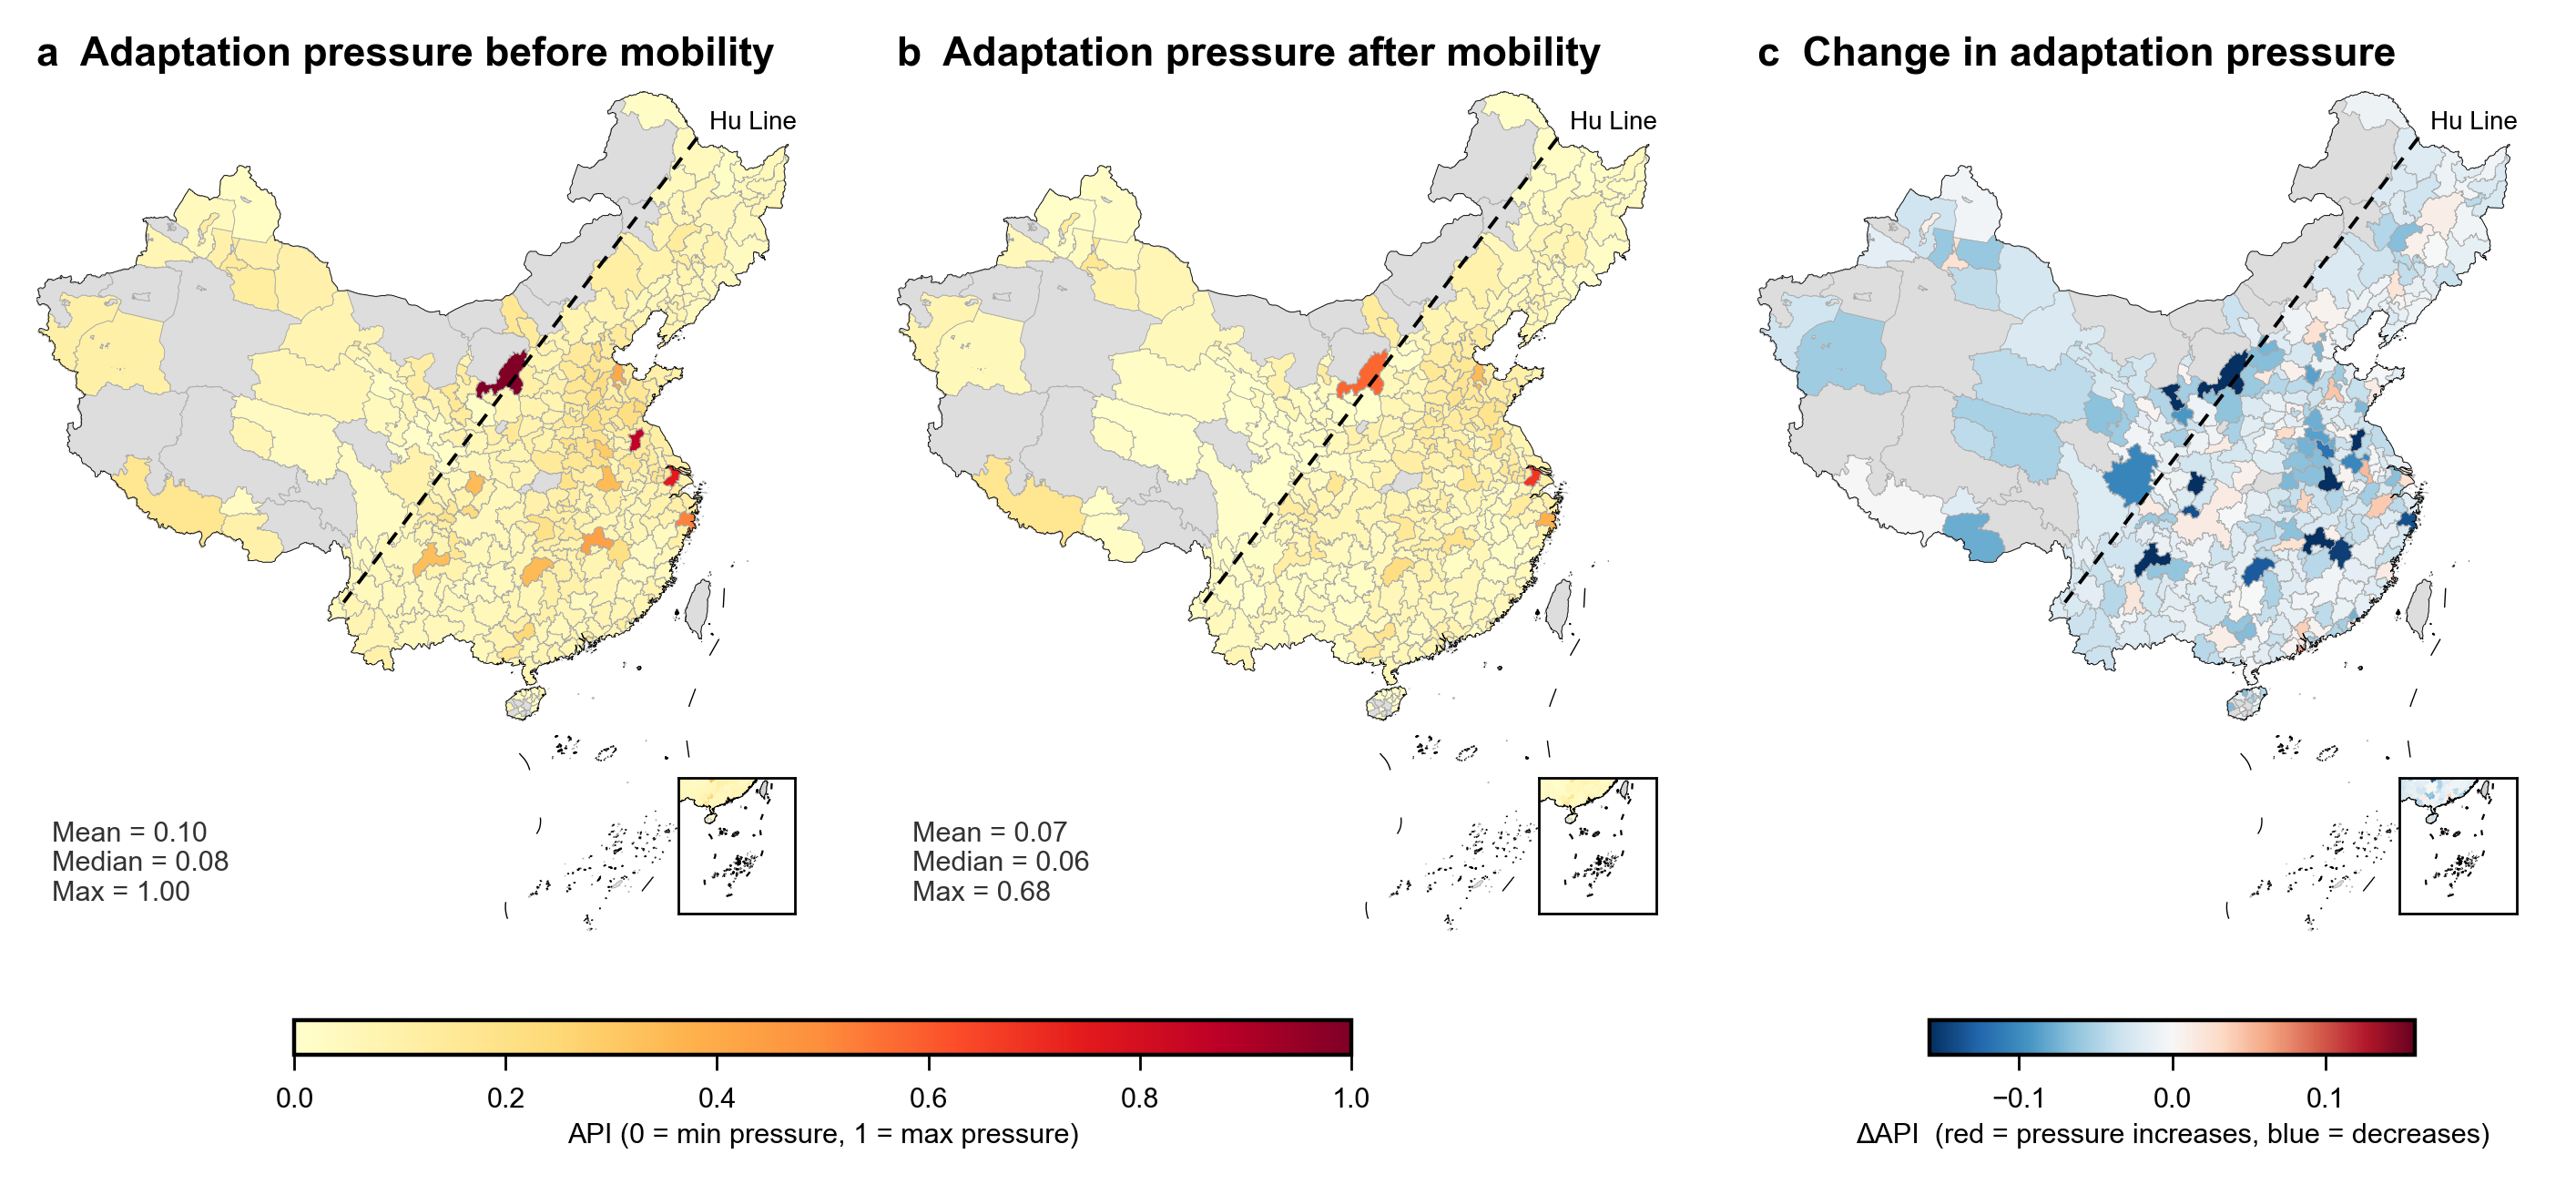

In [130]:
# =============================================================================
# Fig4: Adaptation Pressure Index (API) — 3 choropleth maps
# Maps: API before / API after / ΔAPI
# Format aligned with Fig3
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from shapely.geometry import box as shapely_box
from pyproj import Transformer
from adjustText import adjust_text

# ── 0. Paths & settings ───────────────────────────────────────────────────────
FLOW_DIR   = Path("/Volumes/UCL/论文工作/空气污染/cross_flow_truncated/averaged_results/flow_avg")
LOCAL_DIR  = Path("/Volumes/UCL/论文工作/空气污染/health_burden/air_scenarios_5/city_patient_sum")
INPUT_FILE = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/air_pollution/data source/hospital/13-National hospital directory.xlsx")
SHP_PATH   = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/city_shp/shi_en.shp")
CHINA_SHP  = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国底图-中图社审过版本/中国底图/中国面.shp")
CHINA_SHP2 = Path("/Users/shirley/Library/CloudStorage/OneDrive-UniversityCollegeLondon/Desktop/中国国界线/九段线/九段线和群岛.shp")
OUTFILE    = Path("/Users/shirley/Desktop/plots_V2/Fig4_API_maps.png")
OUTFILE.parent.mkdir(parents=True, exist_ok=True)

SCENARIO = "earlypeak_NZ_CL"
YEARS    = [2020, 2030, 2040, 2050, 2060]
PROJ_STR = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

CITY_NAME_MAP = {
    "Wulumuqi":  "Urumqi",
    "Xian":      "Xi'an",
    "Qiqihaer":  "Qiqihar",
    "Huhehaote": "Hohhot",
    "Haerbin":   "Harbin",
}

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "axes.titlepad":    2,
})

# ── 2. Spatial data ───────────────────────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)

city_shp_raw = gpd.read_file(SHP_PATH)
city_shp_raw["English"] = city_shp_raw["English"].str.strip().map(
    lambda x: CITY_NAME_MAP.get(x, x))
city_shp = city_shp_raw.to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y  = _hhy_transformer.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = city_shp.geometry.centroid.x
_cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")
region_map = (
    city_shp[["English", "region"]]
    .drop_duplicates(subset="English")
    .set_index("English")["region"]
    .to_dict()
)

# ── 3. Data loaders ───────────────────────────────────────────────────────────
def rename_idx(idx):
    return idx.str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))

def load_flow_matrix(year):
    path = FLOW_DIR / f"flow_patientnum_avg_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path, index_col=0)
    df.index   = rename_idx(df.index)
    df.columns = rename_idx(df.columns)
    df = df.loc[~df.index.isin(["total"]), ~df.columns.isin(["total"])]
    np.fill_diagonal(df.values, 0)
    return df

def load_citysum(year):
    path = LOCAL_DIR / f"citysum_{SCENARIO}_{year}.csv"
    df   = pd.read_csv(path)
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["local_patient", "mo_total"]].sum()

def compute_year(year):
    df_flow  = load_flow_matrix(year)
    df_local = load_citysum(year)
    inflow   = df_flow.sum(axis=0).groupby(level=0).sum()
    outflow  = df_flow.sum(axis=1).groupby(level=0).sum()
    all_cities = inflow.index.union(outflow.index)
    inflow   = inflow.reindex(all_cities, fill_value=0)
    outflow  = outflow.reindex(all_cities, fill_value=0)
    net      = (inflow - outflow).rename("net")
    df_local = df_local.groupby(level=0).sum()
    common   = net.index.intersection(df_local.index)
    out      = df_local.loc[common].copy()
    out["net"]    = net.loc[common].values
    out["demand"] = out["net"] + out["local_patient"]
    return out

# ── 4. Resource (static) ─────────────────────────────────────────────────────
def load_resource():
    df = pd.read_excel(INPUT_FILE, sheet_name="fig4")
    df = df[["city", "beds", "clinics"]].copy()
    df["beds"]    = pd.to_numeric(df["beds"],    errors="coerce")
    df["clinics"] = pd.to_numeric(df["clinics"], errors="coerce")
    df = df.dropna(subset=["city", "beds", "clinics"])
    df = df[(df["beds"] > 0) & (df["clinics"] > 0)]
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    df["resource"] = np.log(df["beds"] * df["clinics"])
    return df.groupby("city")["resource"].sum()

# ── 5. Compute API ────────────────────────────────────────────────────────────
def compute_api(resource):
    frames = [compute_year(y) for y in YEARS]
    avg    = pd.concat(frames).groupby(level=0).mean()
    common = avg.index.intersection(resource.index)
    avg    = avg.loc[common]
    res    = resource.loc[common]

    raw_before = avg["mo_total"] / res
    raw_after  = avg["demand"]   / res
    global_max = max(raw_before.max(), raw_after.max())

    api_before = raw_before / global_max
    api_after  = raw_after  / global_max
    delta_api  = api_after - api_before

    return pd.DataFrame({
        "city":       common,
        "API_before": api_before.values,
        "API_after":  api_after.values,
        "delta_API":  delta_api.values,
    })

# ── 6. Gini coefficient ───────────────────────────────────────────────────────
def gini(arr):
    """Gini coefficient for a 1-D array of non-negative values."""
    a = np.array(arr, dtype=float)
    a = a[~np.isnan(a)]
    a = a[a >= 0]
    a = np.sort(a)
    n = len(a)
    if n == 0 or a.sum() == 0:
        return np.nan
    idx = np.arange(1, n + 1)
    return (2 * np.sum(idx * a) / (n * a.sum())) - (n + 1) / n

# ── 7. Merge with shapefile ───────────────────────────────────────────────────
def build_shp(api_df):
    return city_shp.merge(api_df, left_on="English", right_on="city", how="left")

# ── 8. Nanhai inset helper ────────────────────────────────────────────────────
def _add_nanhai_inset(parent_ax, shp, col, norm, cmap):
    x1, y1, x2, y2 = _NANHAI_BOUNDS
    axins = parent_ax.inset_axes([0.82, 0.02, 0.15, 0.18])
    axins.set_facecolor("white")
    shp.plot(column=col, ax=axins, cmap=cmap, norm=norm,
             linewidth=0, missing_kwds={"color": "lightgrey"})
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)
    pad_x = (x2 - x1) * 0.08
    pad_y = (y2 - y1) * 0.08
    axins.set_xlim(x1 - pad_x, x2 + pad_x)
    axins.set_ylim(y1 - pad_y, y2 + pad_y)
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in axins.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")
        spine.set_clip_on(False)

# ── 9. Map base ───────────────────────────────────────────────────────────────
def _map_base(ax, shp, col, norm, cmap, title, panel):
    shp.plot(column=col, ax=ax, cmap=cmap, norm=norm,
             linewidth=0.15, edgecolor="#AAAAAA",
             missing_kwds={"color": "#DDDDDD"})
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.25)
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.7,
            linestyle="--", dashes=(4, 3), zorder=5)
    ax.text(_HHY_X[0] + 80000, _HHY_Y[0] + 60000,
            "Hu Line", fontsize=5, color="black", zorder=5)
    xmin, ymin, xmax, ymax = china_border.total_bounds
    height = ymax - ymin
    width  = xmax - xmin
    ax.set_xlim(xmin, xmax + width * 0.04)
    ax.set_ylim(ymin + height * 0.01, ymax + height * 0.01)
    ax.set_axis_off()
    ax.text(0, 1.01, f"{panel}  {title}",
            transform=ax.transAxes,
            fontsize=8, fontweight="bold",
            va="bottom", ha="left")
    _add_nanhai_inset(ax, shp, col, norm, cmap)

# ── 10. Map drawing functions ─────────────────────────────────────────────────
def draw_api_map(ax, shp, col, title, panel, norm, cmap,
                 stats=None, label_thresh=0.6):
    """API before/after map — labels high-pressure cities, annotates stats."""
    _map_base(ax, shp, col, norm, cmap, title, panel)

    # Stats annotation — bottom left
    if stats is not None:
        mean_v, median_v, max_v = stats
        ax.text(0.02, 0.04,
                f"Mean = {mean_v:.2f}\nMedian = {median_v:.2f}\nMax = {max_v:.2f}",
                transform=ax.transAxes,
                fontsize=5.5, color="#333333",
                va="bottom", ha="left",
        )

    # City labels for API > threshold
    labeled = shp[shp[col] > label_thresh].dropna(subset=[col])
    texts = []
    for _, row in labeled.iterrows():
        if pd.isna(row.geometry):
            continue
        cx_r = row.geometry.centroid.x
        cy_r = row.geometry.centroid.y
        val  = row[col]
        name = row["English"]



def draw_delta_map(ax, shp, norm, cmap, title, panel):
    """ΔAPI diverging map — labels top 3 increase and top 3 decrease cities."""
    _map_base(ax, shp, "delta_API", norm, cmap, title, panel)
    top3_in  = shp.nlargest(3,  "delta_API").dropna(subset=["delta_API"])
    top3_out = shp.nsmallest(3, "delta_API").dropna(subset=["delta_API"])
    texts = []
    for _, row in pd.concat([top3_in, top3_out]).iterrows():
        if pd.isna(row.geometry):
            continue
        cx_r = row.geometry.centroid.x
        cy_r = row.geometry.centroid.y
        val  = row["delta_API"]
        name = row["English"]


# ── 11. Main plot ─────────────────────────────────────────────────────────────
def plot_fig4(shp, api_df):

    norm_api   = Normalize(vmin=0, vmax=1)
    cmap_api   = "YlOrRd"
    dmax       = shp["delta_API"].abs().quantile(0.98)
    norm_delta = TwoSlopeNorm(vmin=-dmax, vcenter=0, vmax=dmax)
    cmap_delta = "RdBu_r"

    # Compute stats before drawing
    def api_stats(col):
        v = api_df[col].dropna()
        v = v.clip(lower=0)
        return v.mean(), v.median(), v.max()

    stats_before = api_stats("API_before")
    stats_after  = api_stats("API_after")
    print(f"  Before — mean={stats_before[0]:.2f}, median={stats_before[1]:.2f}, max={stats_before[2]:.2f}")
    print(f"  After  — mean={stats_after[0]:.2f}, median={stats_after[1]:.2f}, max={stats_after[2]:.2f}")

    fig = plt.figure(figsize=(18 / 2.54, 8 / 2.54), dpi=400, facecolor="white")
    gs  = GridSpec(
        1, 3,
        figure=fig,
        hspace=0.0, wspace=0.10,
        left=0.0, right=0.97,
        top=0.97,  bottom=0.18,
    )
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    draw_api_map(ax1, shp, "API_before",
                 "Adaptation pressure before mobility", "a",
                 norm_api, cmap_api, stats=stats_before)
    draw_api_map(ax2, shp, "API_after",
                 "Adaptation pressure after mobility", "b",
                 norm_api, cmap_api, stats=stats_after)
    draw_delta_map(ax3, shp, norm_delta, cmap_delta,
                   "Change in adaptation pressure", "c")

    # ── Colorbars ─────────────────────────────────────────────────────────────
    fig.canvas.draw()
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    pos3 = ax3.get_position()

    cbar_h      = 0.03
    cbar_bottom = pos1.y0 - 0.10

    cbar_ax_ab = fig.add_axes([
        pos1.x0 + 0.10, cbar_bottom,
        pos2.x1 * 0.80 - (pos1.x0 + 0.10), cbar_h,
    ])
    sm_ab = mcm.ScalarMappable(cmap=cmap_api, norm=norm_api)
    sm_ab.set_array([])
    cbar_ab = fig.colorbar(sm_ab, cax=cbar_ax_ab, orientation="horizontal")
    cbar_ab.ax.tick_params(labelsize=5.5)
    cbar_ab.set_label("API (0 = min pressure, 1 = max pressure)",
                      fontsize=5.5, labelpad=2)

    cbar_ax_c = fig.add_axes([
        pos3.x0 * 1.1, cbar_bottom,
        pos3.x1 * 0.95 - pos3.x0 * 1.1, cbar_h,
    ])
    sm_c = mcm.ScalarMappable(cmap=cmap_delta, norm=norm_delta)
    sm_c.set_array([])
    cbar_c = fig.colorbar(sm_c, cax=cbar_ax_c, orientation="horizontal")
    cbar_c.ax.tick_params(labelsize=5.5)
    cbar_c.set_label("ΔAPI  (red = pressure increases, blue = decreases)",
                     fontsize=5.5, labelpad=2)

    fig.savefig(OUTFILE, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"Saved -> {OUTFILE}")
    plt.show()

# ── 12. Main ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Loading resource data...")
    resource = load_resource()
    print(f"  {len(resource)} cities with resource data")

    print("Computing API (2020-2060 average)...")
    api_df = compute_api(resource)
    print(f"  {len(api_df)} cities matched")

    print("\nTop 10 cities by API_before:")
    print(api_df.nlargest(10, "API_before")[
        ["city", "API_before", "API_after", "delta_API"]
    ].to_string(index=False))

    csv_path = OUTFILE.parent / "api_city.csv"
    api_df.to_csv(csv_path, index=False)
    print(f"  CSV saved -> {csv_path}")

    print("\nMerging with shapefile...")
    shp = build_shp(api_df)

    print("Plotting Fig4...")
    plot_fig4(shp, api_df)